# GraphRAG v2 Playground

Use this notebook to test GraphRAG v2 (`/query_v2`) on your ingested resources.

- visualize returned evidence paths,
- inspect answers and citations,
- quickly try different prompts.

## Why only v2
The legacy v1 path (`/query`, Cypher QA chain) was removed after local URL/PDF ingestion tests showed unreliable behavior and invalid Cypher generation.

## Where ingestion happens in this notebook
Ingestion is available via helper functions in the setup cell:
- `ingest_urls([...])` to ingest web pages,
- `ingest_pdfs([...])` to ingest local PDF files.

## Reset Neo4j from scratch (resource-scoped runs)
To avoid unbounded accumulation of resources, run experiments on a fresh Neo4j state and ingest only the specific URLs/PDFs you want for that run.

From `DocsBasedSupport/`:

```bash
docker compose down -v
docker compose up -d
```

Then start API again and ingest your selected resources:

```bash
uvicorn app.main:app --reload
```

In [1]:
from __future__ import annotations

import textwrap
from typing import Any

import matplotlib.pyplot as plt
import networkx as nx
import requests
from IPython.display import Markdown, display
from ipywidgets import Button, HBox, Output, Textarea, VBox

In [2]:
BASE_URL = "http://127.0.0.1:8000"


def ask(endpoint: str, question: str) -> dict[str, Any]:
    resp = requests.post(
        f"{BASE_URL}{endpoint}",
        json={"question": question},
        timeout=120,
    )
    resp.raise_for_status()
    return resp.json()


def ingest_payload(pdf_paths: list[str] | None = None, urls: list[str] | None = None) -> dict[str, Any]:
    payload = {
        "pdf_paths": pdf_paths or [],
        "urls": urls or [],
    }
    resp = requests.post(f"{BASE_URL}/ingest", json=payload, timeout=300)
    resp.raise_for_status()
    return resp.json()


def ingest_urls(urls: list[str]) -> dict[str, Any]:
    return ingest_payload(urls=urls)


def ingest_pdfs(pdf_paths: list[str]) -> dict[str, Any]:
    return ingest_payload(pdf_paths=pdf_paths)


def build_graph(payload: dict[str, Any]) -> nx.MultiDiGraph:
    g = nx.MultiDiGraph()
    for edge in payload.get("evidence_path", []):
        src = edge.get("source", "UNKNOWN")
        rel = edge.get("relationship", "AFFECTS")
        dst = edge.get("target", "UNKNOWN")
        g.add_edge(src, dst, label=rel)
    return g


def draw_graph(payload: dict[str, Any], title: str) -> None:
    g = build_graph(payload)
    if g.number_of_nodes() == 0:
        print(f"{title}: no evidence edges returned")
        return

    plt.figure(figsize=(10, 6))
    pos = nx.spring_layout(g, seed=42)
    nx.draw(
        g,
        pos,
        with_labels=True,
        node_size=2200,
        node_color="#e8f0fe",
        font_size=9,
        arrows=True,
    )
    labels = {(u, v, k): d.get("label", "") for u, v, k, d in g.edges(keys=True, data=True)}
    nx.draw_networkx_edge_labels(g, pos, edge_labels=labels, font_size=8)
    plt.title(title)
    plt.axis("off")
    plt.show()


def print_response(name: str, payload: dict[str, Any]) -> None:
    answer = payload.get("answer", "")
    display(Markdown(f"### {name} answer"))
    display(Markdown(answer if str(answer).strip() else "_(empty answer)_"))

    citations = payload.get("citations", [])
    display(Markdown(f"**{name} citations ({len(citations)}):**"))
    for idx, c in enumerate(citations[:5], start=1):
        source_id = c.get("source_id", "")
        location = c.get("source_location", "")
        quote = (c.get("quote") or "").replace("\n", " ")[:180]
        print(f"{idx}. source_id={source_id} | source_location={location}")
        if quote:
            print(f"   quote: {quote}")
    if len(citations) > 5:
        print(f"... {len(citations) - 5} more citations")


def query_v2(question: str) -> dict[str, Any]:
    payload = ask("/query_v2", question)

    display(Markdown(f"## Question\n`{question}`"))
    print_response("v2 (/query_v2)", payload)
    draw_graph(payload, "v2 evidence graph")
    return payload

In [3]:
# YAML configuration helper: edit values, preview YAML, and optionally write settings.yaml.
from pathlib import Path

import yaml

CONFIG = {
    # LLM provider + models
    "llm_provider": "ollama",  # ollama | openai | gemini
    "llm_extract_model": "gpt-oss:120b-cloud",
    "llm_chat_model": "gpt-oss:120b-cloud",
    "llm_embed_model": "nomic-embed-text",

    # Optional provider endpoint (used mainly for local/provider-specific routing)
    "llm_base_url": "http://localhost:11434",

    # GraphRAG v2 retrieval/index settings
    "graphrag_v2_index_name": "chunk_embeddings",
    "graphrag_v2_embedding_dims": 768,
    "graphrag_v2_top_k": 5,

    # Neo4j connection
    "neo4j_uri": "bolt://localhost:7687",
    "neo4j_database": "neo4j",

    # Temporal refresh behavior
    "temporal_refresh_minutes": 60,
    "temporal_http_timeout_seconds": 30,
}

SETTINGS_PATH = Path("../settings.yaml").resolve()

print(f"Target settings.yaml path: {SETTINGS_PATH}")
print("\n--- YAML preview ---")
print(yaml.safe_dump(CONFIG, sort_keys=False, allow_unicode=False))

# To write these values into DocsBasedSupport/settings.yaml, uncomment:
# SETTINGS_PATH.write_text(yaml.safe_dump(CONFIG, sort_keys=False, allow_unicode=False), encoding="utf-8")
# print(f"Wrote config to: {SETTINGS_PATH}")

Target settings.yaml path: /Users/bkosinski/Desktop/STUDIA/MGR/SecSearch/DocsBasedSupport/settings.yaml

--- YAML preview ---
llm_provider: ollama
llm_extract_model: gpt-oss:120b-cloud
llm_chat_model: gpt-oss:120b-cloud
llm_embed_model: nomic-embed-text
llm_base_url: http://localhost:11434
graphrag_v2_index_name: chunk_embeddings
graphrag_v2_embedding_dims: 768
graphrag_v2_top_k: 5
neo4j_uri: bolt://localhost:7687
neo4j_database: neo4j
temporal_refresh_minutes: 60
temporal_http_timeout_seconds: 30



In [4]:
# Optional: ingest URLs before querying.
# Replace with your target documentation URLs.
URLS_TO_INGEST = [
    "https://github.com/orgs/MGR-WUT",
]

# Uncomment to run:
#ingest_result_urls = ingest_urls(URLS_TO_INGEST)
#ingest_result_urls

In [5]:
# Optional: ingest local PDFs before querying.
# Use absolute paths or paths relative to the API working directory.
PDFS_TO_INGEST = [
    "/Users/bkosinski/Downloads/bkosinski_master_thesis.pdf",
]

# Uncomment to run:
ingest_result_pdfs = ingest_pdfs(PDFS_TO_INGEST)
ingest_result_pdfs

{'ingested': 1,
 'details': [{'source_id': 'pdf:bkosinski_master_thesis.pdf',
   'entity_count': 7,
   'relation_count': 7,
   'v2_chunks_indexed': 164}]}

## Question
`How does LLLMServer work with ChromeExtension? Which tools are used specifically for each of components?`

### v2 (/query_v2) answer

**How the LLLMServer and the Chrome Extension work together**  The prototype is split into two logical parts:
| Part | What it does | How the two parts talk to each other |
|------|--------------|--------------------------------------| | **Chrome Extension** | Provides the
user‑facing UI (a React/TypeScript‑based popup) that lets a user pick a model, type a prompt and see the
answer. | The extension is configured with a **Proxy URL** and an **API‑key** (generated in OpenWebUI). Every
request the user makes is sent as an HTTP call to that Proxy endpoint. | | **LLLMServer (Proxy + OpenWebUI)**
| Hosts the language‑model backend. The Proxy authenticates the incoming calls, forwards them to the OpenWebUI
API, which in turn talks to a locally‑run LLM engine (by default Ollama). | The Proxy validates the API‑key,
forwards the prompt to OpenWebUI, receives the model’s response, and sends it back to the Chrome extension.
The flow is therefore: **Extension → Proxy → OpenWebUI → Ollama → Proxy →

**v2 (/query_v2) citations (5):**

1. source_id=pdf:bkosinski_master_thesis.pdf | source_location=/Users/bkosinski/Downloads/bkosinski_master_thesis.pdf
   quote: umentation and provides instructions for setting up the Proxy, generating the required API keys from the OpenWebUI instance, and conﬁguring the Proxy component accordingly. In the 
2. source_id=pdf:bkosinski_master_thesis.pdf | source_location=/Users/bkosinski/Downloads/bkosinski_master_thesis.pdf
   quote: ] Bartosz Kosinski,Prototype github organization - experiments, https://github. com/MGR- WUT/LLLMServer/tree/main/experiments , Accessed: 2026-01-02, 2026. 89 List of Figures 1.1 T
3. source_id=pdf:bkosinski_master_thesis.pdf | source_location=/Users/bkosinski/Downloads/bkosinski_master_thesis.pdf
   quote: ment of the Proposed Solution Figure 7.1 shows the default window of the Chrome extension, which should be visible after completing the deployment and installation steps described 
4. source_id=pdf:bkosinski_master_thesis.pdf | source_location=/Users/bko

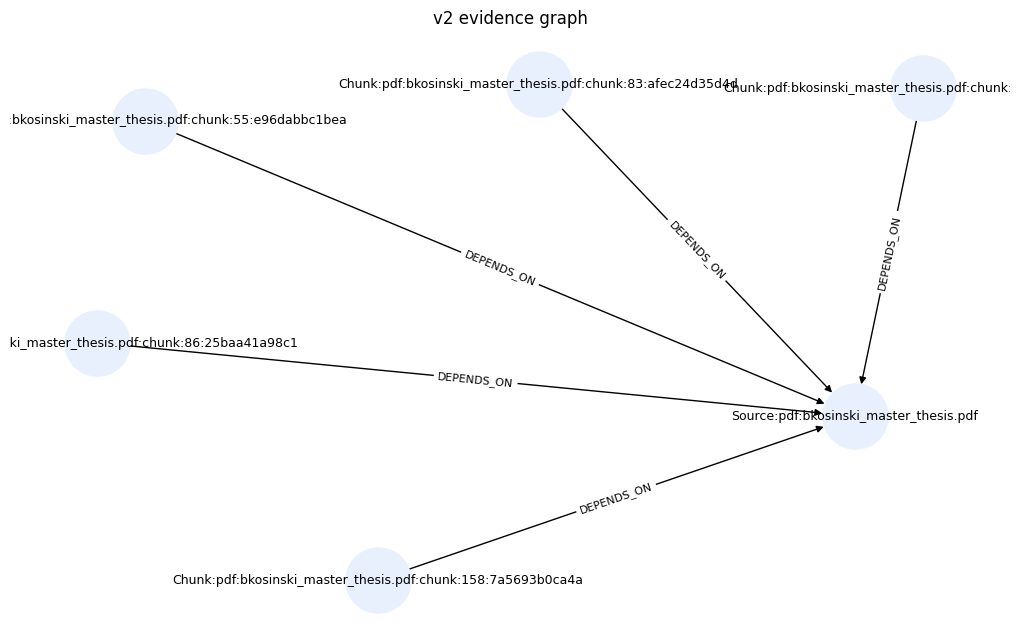

In [6]:
# Quick smoke test on one question.
QUESTION = "How does LLLMServer work with ChromeExtension? Which tools are used specifically for each of components?"
v2_response = query_v2(QUESTION)

In [7]:
# Interactive tester: type a question and run v2.
question_box = Textarea(
    value="Why OpenWebUI was used?",
    description="Question:",
    layout={"width": "900px", "height": "90px"},
)
run_button = Button(description="Run v2", button_style="primary")
out = Output()


def on_click(_):
    with out:
        out.clear_output()
        try:
            query_v2(question_box.value.strip())
        except Exception as exc:
            print(f"Request failed: {exc}")


run_button.on_click(on_click)
display(VBox([question_box, HBox([run_button]), out]))